<a href="https://colab.research.google.com/github/GUC-DM/w25-mini-project-1-ahmed-farahat-t08-eyad-ibrahim-t08/blob/main/regression_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: ahmed mohamed farahat

ID: 58-6422

Tutorial: 8

---

Name: eyad Ibrahim rashed

ID: 58-11744

Tutorial: 8

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error



try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh
...,...,...,...,...,...,...,...,...,...,...,...
1095,BLD-2095-OH,Commercial,Giza,(Dokki50,Saturday,High,Low,1161m2,2022-04-21,27.85,3010.81 kWh
1096,BLD-2096-RH,Residential,NaN,Dokki-71,Sunday,Medium,Medium,37943m2,2024-10-31,36.23,4248.49 kWh
1097,BLD-2097-JZ,Commercial,Giza,_Mohandessin91,SunDay,Low,Medium,1558,2021-04-18,20.00,2843.6 kWh
1098,BLD-2098-ZP,Industrial,Alexandria,*23Smouha,saturday,Medium,Low,2145,2023-09-14,34.43,3348.39 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB


genaral info about the coulumns and the non-null values so most of the features have low non null values so we can decide the technique we will use because if the msiing data was too much we wouldve decided to remove some attributes


most involving features in estimating bulding electricity consumption is(Building_Type  ,Occupancy_Level ,Appliances_Usage_Level, SquareFootage, Last_Maintenance_Date, Average_Temperature, Energy_Consumption) consider also they are not all aurthogonal

In [3]:
df.describe(include='all')

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
count,1100,990,873,1100,1100,1100,1100,1100,1100,990.000000,1100
unique,1100,3,3,848,42,3,3,1095,727,NaN,1100
top,BLD-2099-GL,Residential,Alexandria,Smouha,Sunday,High,Low,49653m2,2024-12-31,NaN,4722.59 kWh
freq,1,349,310,45,54,368,381,2,89,NaN,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.499404,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.703806,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.910000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.422500,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.260000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.970000,NaN


this describe that include alll this function  calculates the number of unique values, the most common value and its frequency for each non-numeric column it give us extra overall idea knowing that the null values affecting the results so cleaning will be needed


In [4]:
df.describe()

,Average_Temperature
count,990.000000
mean,33.499404
std,10.703806
min,-4.910000
25%,29.422500
50%,35.260000
75%,39.970000
max,50.000000


the catigorical values need to be standralized

In [5]:
df.mean(numeric_only=True)

,0
Average_Temperature,33.499404


i need to convert the data types for the features to be able to compute statistical data from it to be done next step

## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

convert the 'Energy_Consumption' to float to be able to preform mathmatical operations on it also the squareFootage to int


In [6]:
df['Energy_Consumption'] = df['Energy_Consumption'].astype(str).str.replace(' kWh', '', regex=False)
df['Energy_Consumption'] = pd.to_numeric(df['Energy_Consumption'], errors='coerce')
df['SquareFootage'] = df['SquareFootage'].astype(str).str.replace('m2', '', regex=False)
df['SquareFootage'] = pd.to_numeric(df['SquareFootage'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   int64  
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 94.7+ KB


make the features name complete by adding (Kw) and (M2)

In [7]:
df = df.rename(columns={'SquareFootage': 'SquareFootage(M2)', 'Energy_Consumption': 'Energy_Consumption(KW)'})
display(df.head())

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage(M2),Last_Maintenance_Date,Average_Temperature,Energy_Consumption(KW)
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17


make the Neighborhood consistent


In [8]:
df['Neighborhood']=df['Neighborhood'].str.extract('([a-zA-Z\\s]+)', expand=False).str.strip()
df.head(20)

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage(M2),Last_Maintenance_Date,Average_Temperature,Energy_Consumption(KW)
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,Mohandessin,tuesDAY,High,High,44372,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24
3,BLD-1003-HE,NaN,NaN,Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17
5,BLD-1005-VX,Commercial,NaN,New Cairo,SunDay,Low,Medium,37377,2022-07-31,37.54,4687.67
6,BLD-1006-RC,Industrial,Cairo,Heliopolis,saturDAY,High,Low,38638,2023-07-07,50.00,5526.83
7,BLD-1007-SN,Residential,Cairo,New Cairo,tuesDAY,Medium,Low,34950,2020-07-29,38.51,4116.32
8,BLD-1008-BA,Industrial,Alexandria,Gleem,MoNday,High,High,29741,2024-12-31,43.62,5841.65
9,BLD-1009-CG,Residential,NaN,Mohandessin,FRIDAY,Medium,High,17467,2023-01-14,33.18,3419.13


fix the date data type

In [9]:
df['Last_Maintenance_Date']=pd.to_datetime(df['Last_Maintenance_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Building_ID             1100 non-null   object        
 1   Building_Type           990 non-null    object        
 2   Governorate             873 non-null    object        
 3   Neighborhood            1100 non-null   object        
 4   Day_of_Week             1100 non-null   object        
 5   Occupancy_Level         1100 non-null   object        
 6   Appliances_Usage_Level  1100 non-null   object        
 7   SquareFootage(M2)       1100 non-null   int64         
 8   Last_Maintenance_Date   1100 non-null   datetime64[ns]
 9   Average_Temperature     990 non-null    float64       
 10  Energy_Consumption(KW)  1100 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 94.7+ KB


In [10]:
df.isna().sum()

,0
Building_ID,0
Building_Type,110
Governorate,227
Neighborhood,0
Day_of_Week,0
Occupancy_Level,0
Appliances_Usage_Level,0
SquareFootage(M2),0
Last_Maintenance_Date,0
Average_Temperature,110


make the 'Day_of_Week' consistent to the acctual week days name by using contain so if the word contain the begining of the day characters it will match it

In [11]:

df['Day_of_Week'] = df['Day_of_Week'].str.lower()
df.loc[df['Day_of_Week'].str.contains('mon', na=False), 'Day_of_Week'] = 'Monday'
df.loc[df['Day_of_Week'].str.contains('tue', na=False), 'Day_of_Week'] = 'Tuesday'
df.loc[df['Day_of_Week'].str.contains('wed', na=False), 'Day_of_Week'] = 'Wednesday'
df.loc[df['Day_of_Week'].str.contains('thu', na=False), 'Day_of_Week'] = 'Thursday'
df.loc[df['Day_of_Week'].str.contains('fri', na=False), 'Day_of_Week'] = 'Friday'
df.loc[df['Day_of_Week'].str.contains('sat', na=False), 'Day_of_Week'] = 'Saturday'
df.loc[df['Day_of_Week'].str.contains('sun', na=False), 'Day_of_Week'] = 'Sunday'


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Building_ID             1100 non-null   object        
 1   Building_Type           990 non-null    object        
 2   Governorate             873 non-null    object        
 3   Neighborhood            1100 non-null   object        
 4   Day_of_Week             1100 non-null   object        
 5   Occupancy_Level         1100 non-null   object        
 6   Appliances_Usage_Level  1100 non-null   object        
 7   SquareFootage(M2)       1100 non-null   int64         
 8   Last_Maintenance_Date   1100 non-null   datetime64[ns]
 9   Average_Temperature     990 non-null    float64       
 10  Energy_Consumption(KW)  1100 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 94.7+ KB


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Building_ID             1100 non-null   object        
 1   Building_Type           990 non-null    object        
 2   Governorate             873 non-null    object        
 3   Neighborhood            1100 non-null   object        
 4   Day_of_Week             1100 non-null   object        
 5   Occupancy_Level         1100 non-null   object        
 6   Appliances_Usage_Level  1100 non-null   object        
 7   SquareFootage(M2)       1100 non-null   int64         
 8   Last_Maintenance_Date   1100 non-null   datetime64[ns]
 9   Average_Temperature     990 non-null    float64       
 10  Energy_Consumption(KW)  1100 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 94.7+ KB


i will fill the Governorate using the complete data in the neighborhood so when ever neighborhood face a NaN it will fill it with the corresponding Governorate based on old data we have since we hace already some correspondings

In [13]:
df['Neighborhood'].unique()

array(['Smouha', 'Mohandessin', 'New Cairo', 'Dokki', 'Heliopolis',
       'Gleem', 'Maadi'], dtype=object)

here we we knew the unqiue neighborhoods we have so that we can assign them to governartes

In [14]:
temp = df[['Governorate', 'Neighborhood']]
display(temp.head(20))

,Governorate,Neighborhood
0,Alexandria,Smouha
1,Giza,Mohandessin
2,Cairo,New Cairo
3,NaN,Dokki
4,Alexandria,Smouha
5,NaN,New Cairo
6,Cairo,Heliopolis
7,Cairo,New Cairo
8,Alexandria,Gleem
9,NaN,Mohandessin


In [15]:
print(df['Neighborhood'].unique())

['Smouha' 'Mohandessin' 'New Cairo' 'Dokki' 'Heliopolis' 'Gleem' 'Maadi']


In [16]:
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'Dokki'), 'Governorate'] = 'Giza'
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'Mohandessin'), 'Governorate'] = 'Giza'
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'Gleem'), 'Governorate'] = 'Alexandria'
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'Smouha'), 'Governorate'] = 'Alexandria'
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'New Cairo'), 'Governorate'] = 'Cairo'
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'Heliopolis'), 'Governorate'] = 'Cairo'
df.loc[(df['Governorate'].isna()) & (df['Neighborhood'] == 'Maadi'), 'Governorate'] = 'Cairo'
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Building_ID             1100 non-null   object        
 1   Building_Type           990 non-null    object        
 2   Governorate             1100 non-null   object        
 3   Neighborhood            1100 non-null   object        
 4   Day_of_Week             1100 non-null   object        
 5   Occupancy_Level         1100 non-null   object        
 6   Appliances_Usage_Level  1100 non-null   object        
 7   SquareFootage(M2)       1100 non-null   int64         
 8   Last_Maintenance_Date   1100 non-null   datetime64[ns]
 9   Average_Temperature     990 non-null    float64       
 10  Energy_Consumption(KW)  1100 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 94.7+ KB


In [17]:
df.describe()


,SquareFootage(M2),Last_Maintenance_Date,Average_Temperature,Energy_Consumption(KW)
count,1100.000000,1100,990.000000,1100.000000
mean,25500.527273,2022-06-28 01:23:46.909090816,33.499404,4168.191273
min,560.000000,2020-01-01 00:00:00,-4.910000,1683.950000
25%,13203.750000,2021-03-06 00:00:00,29.422500,3510.460000
50%,25785.500000,2022-07-04 00:00:00,35.260000,4189.690000
75%,37536.750000,2023-10-05 12:00:00,39.970000,4859.510000
max,49997.000000,2024-12-31 00:00:00,50.000000,6530.600000
std,14236.955632,NaN,10.703806,924.278723


i filled the NaN of the temprature with the average temprature of other similar neighbor since it is more relevant to the area to have closer range of usage but i found it is not that deference so it will be only additional computation that is not important and the mean is sufficient also the SD is low so its a good indication

In [18]:
temp2 = df.groupby('Neighborhood')
temp2['Average_Temperature'].describe()

,count,mean,std,min,25%,50%,75%,max
Neighborhood,,,,,,,,
Dokki,165.0,34.701636,9.592991,-4.84,29.550,36.500,40.3100,50.00
Gleem,173.0,32.651272,11.926121,-4.77,28.780,34.600,40.2900,50.00
Heliopolis,83.0,33.046747,10.649580,-4.91,29.800,33.980,37.9450,50.00
Maadi,100.0,33.480800,10.608803,-4.86,29.535,34.785,40.0475,50.00
Mohandessin,151.0,32.372318,11.595219,-3.68,28.965,34.210,39.2050,48.42
New Cairo,129.0,34.887442,9.298241,-4.66,30.550,36.720,40.3100,50.00
Smouha,189.0,33.387884,10.633250,-4.36,29.140,34.970,39.7100,50.00


In [19]:
meanTemp = df['Average_Temperature'].mean()
df['Average_Temperature'] = df['Average_Temperature'].fillna(meanTemp)


df.head(30).isna().sum()

,0
Building_ID,0
Building_Type,2
Governorate,0
Neighborhood,0
Day_of_Week,0
Occupancy_Level,0
Appliances_Usage_Level,0
SquareFootage(M2),0
Last_Maintenance_Date,0
Average_Temperature,0


 to fill the NaN in bilding the most repeated type in the neighborhood type can be good fit because of the nature of area since it is hard to find for example a factory in between residential area and also each area have its own temparture etc.





In [20]:
df['Building_Type'] = df.groupby('Neighborhood')['Building_Type'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None))

df.isna().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Building_ID             1100 non-null   object        
 1   Building_Type           1100 non-null   object        
 2   Governorate             1100 non-null   object        
 3   Neighborhood            1100 non-null   object        
 4   Day_of_Week             1100 non-null   object        
 5   Occupancy_Level         1100 non-null   object        
 6   Appliances_Usage_Level  1100 non-null   object        
 7   SquareFootage(M2)       1100 non-null   int64         
 8   Last_Maintenance_Date   1100 non-null   datetime64[ns]
 9   Average_Temperature     1100 non-null   float64       
 10  Energy_Consumption(KW)  1100 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 94.7+ KB


feature engineering for Days_since_last_maintenance

i will get today time stamp - Last_Maintenance_Date and join the feature



In [21]:

given_date = datetime(2025, 10, 26).date()
df['Days_since_last_maintenance'] = (given_date - df['Last_Maintenance_Date'].dt.date).apply(lambda x: x.days)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Building_ID                  1100 non-null   object        
 1   Building_Type                1100 non-null   object        
 2   Governorate                  1100 non-null   object        
 3   Neighborhood                 1100 non-null   object        
 4   Day_of_Week                  1100 non-null   object        
 5   Occupancy_Level              1100 non-null   object        
 6   Appliances_Usage_Level       1100 non-null   object        
 7   SquareFootage(M2)            1100 non-null   int64         
 8   Last_Maintenance_Date        1100 non-null   datetime64[ns]
 9   Average_Temperature          1100 non-null   float64       
 10  Energy_Consumption(KW)       1100 non-null   float64       
 11  Days_since_last_maintenance  1100 non-null 

feature engineering for Day_type will be if contained any of the SUN,mon,tue,wed = weekday else weekend

In [22]:
weekdays_contains = ['sun', 'mon', 'tue', 'wed']

df['Day_type'] = 'weekend'

df.loc[df['Day_of_Week'].str.lower().str.contains('|'.join(weekdays_contains), na=False), 'Day_type'] = 'weekday'

df.head(20)

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage(M2),Last_Maintenance_Date,Average_Temperature,Energy_Consumption(KW),Days_since_last_maintenance,Day_type
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063,2020-01-01,28.610000,2713.95,2125,weekday
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372,2022-02-24,33.499404,5744.99,1340,weekday
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255,2021-02-22,37.880000,4101.24,1707,weekday
3,BLD-1003-HE,Industrial,Giza,Dokki,Tuesday,Low,High,13265,2023-07-30,35.060000,3009.14,819,weekday
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17,1171,weekday
5,BLD-1005-VX,Commercial,Cairo,New Cairo,Sunday,Low,Medium,37377,2022-07-31,37.540000,4687.67,1183,weekday
6,BLD-1006-RC,Industrial,Cairo,Heliopolis,Saturday,High,Low,38638,2023-07-07,50.000000,5526.83,842,weekend
7,BLD-1007-SN,Residential,Cairo,New Cairo,Tuesday,Medium,Low,34950,2020-07-29,38.510000,4116.32,1915,weekday
8,BLD-1008-BA,Industrial,Alexandria,Gleem,Monday,High,High,29741,2024-12-31,43.620000,5841.65,299,weekday
9,BLD-1009-CG,Residential,Giza,Mohandessin,Friday,Medium,High,17467,2023-01-14,33.180000,3419.13,1016,weekend


encode Building_Type since i assume it will afect the consumption pattern and useing one hot encode since in is not a related in sequence like a gpa

In [23]:
building_type_encoded = pd.get_dummies(df['Building_Type'], prefix='Building_Type', dtype=int)
df = pd.concat([df, building_type_encoded], axis=1)

display(df.head())

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage(M2),Last_Maintenance_Date,Average_Temperature,Energy_Consumption(KW),Days_since_last_maintenance,Day_type,Building_Type_Commercial,Building_Type_Industrial,Building_Type_Residential
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063,2020-01-01,28.610000,2713.95,2125,weekday,0,0,1
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372,2022-02-24,33.499404,5744.99,1340,weekday,1,0,0
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255,2021-02-22,37.880000,4101.24,1707,weekday,0,1,0
3,BLD-1003-HE,Industrial,Giza,Dokki,Tuesday,Low,High,13265,2023-07-30,35.060000,3009.14,819,weekday,0,1,0
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17,1171,weekday,1,0,0


at this point we have a clean data without missing vales all cleaned and filled by the techniqes we used in the codes above

## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

<BarContainer object of 7 artists>

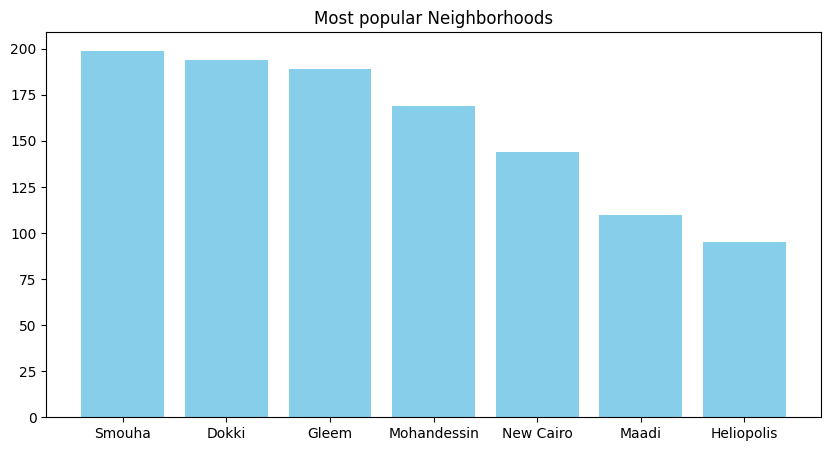

In [24]:
plt.figure(figsize=(10,5))
plt.title('Most popular Neighborhoods')
neighborhood_counts = df['Neighborhood'].value_counts()
neighborhood_counts = neighborhood_counts.sort_values(ascending=False)
plt.bar(neighborhood_counts.index, neighborhood_counts.values, color='skyblue')


**Answer for Q1:** here is a visualization and we can tell from the gragh that the top 3 are smouha dokki gleem and here we used the bar chart becuase we want to dsipaly the frequence of each unqiue value in the column neighborhood so the abr chart was the best option

**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

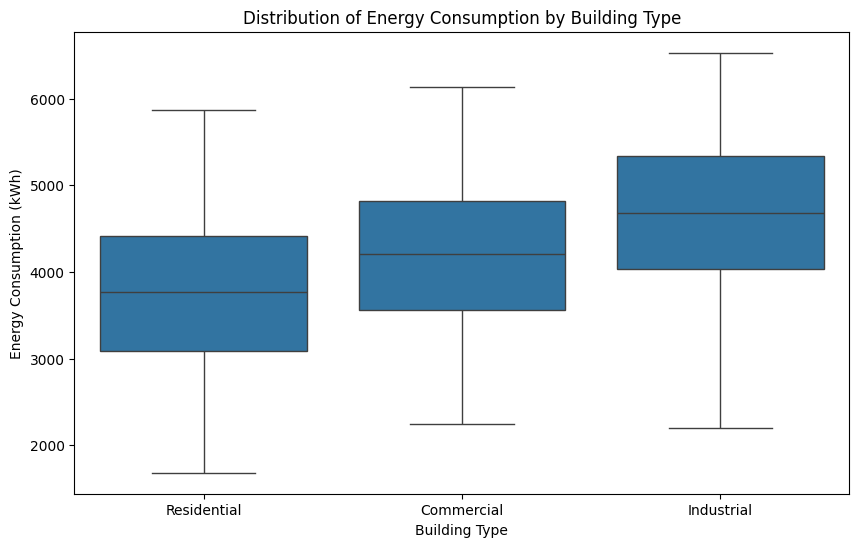

Energy Consumption Statistics by Building Type:


,count,mean,std,min,25%,50%,75%,max
Building_Type,,,,,,,,
Commercial,334.0,4192.837455,820.046604,2241.96,3557.9025,4211.950,4822.2575,6133.65
Industrial,348.0,4650.443908,852.723567,2205.20,4032.1650,4684.545,5333.6225,6530.60
Residential,418.0,3747.005287,858.482855,1683.95,3085.6300,3772.365,4409.9050,5867.13


In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Building_Type', y='Energy_Consumption(KW)', data=df)
plt.title('Distribution of Energy Consumption by Building Type')
plt.xlabel('Building Type')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

print("Energy Consumption Statistics by Building Type:")
display(df.groupby('Building_Type')['Energy_Consumption(KW)'].describe())

**Answer for Q2:** _Your answer here_

- Residential have the highest distribution between all the types since it have the largest standard deviation by 858.48 that means the distribution is wide from its mean
- on average the highest consumption is for the Industrial with mean of 4650

here we fount the boxplot is our best option to shwo the compraiosn between all 3 given us the best visual intrepretation for this and it handle diffrent scales easliy

**Q3:** How does the building size affect energy consumption?

**Visualization**

SquareFootage(M2)           int64
Energy_Consumption(KW)    float64
dtype: object
       SquareFootage(M2)  Energy_Consumption(KW)
count        1100.000000             1100.000000
mean        25500.527273             4168.191273
std         14236.955632              924.278723
min           560.000000             1683.950000
25%         13203.750000             3510.460000
50%         25785.500000             4189.690000
75%         37536.750000             4859.510000
max         49997.000000             6530.600000


/tmp/ipython-input-1364666038.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='SquareFootage(M2)', y='Energy_Consumption(KW)', data=df, palette='magma', ax=ax)


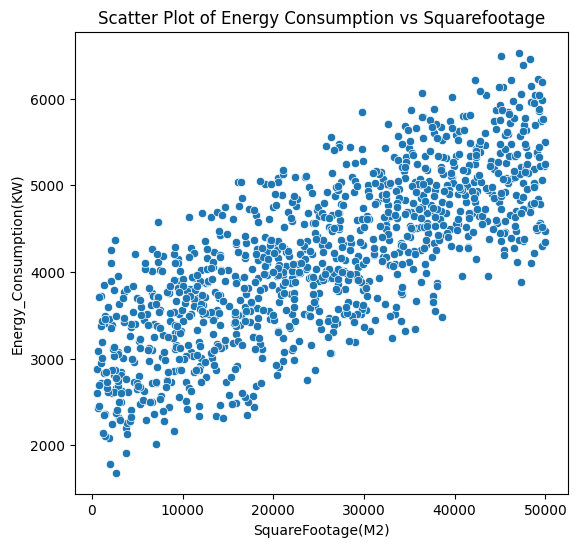

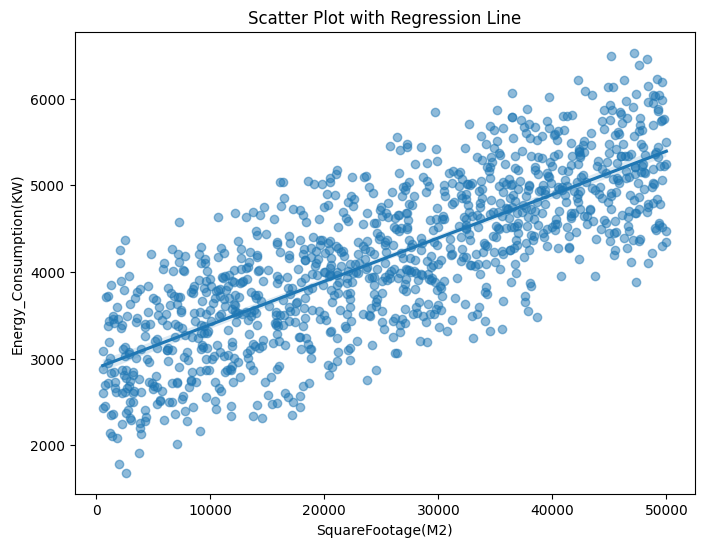

Correlation: 0.7707645406507827


In [26]:
print(df[['SquareFootage(M2)', 'Energy_Consumption(KW)']].dtypes)
print(df[['SquareFootage(M2)', 'Energy_Consumption(KW)']].describe())


f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='SquareFootage(M2)', y='Energy_Consumption(KW)', data=df, palette='magma', ax=ax)
ax.set_title('Scatter Plot of Energy Consumption vs Squarefootage')
plt.show()


plt.figure(figsize=(8, 6))
sns.regplot(x='SquareFootage(M2)', y='Energy_Consumption(KW)', data=df, scatter_kws={'alpha':0.5})
plt.title('Scatter Plot with Regression Line')
plt.show()


correlation = df['SquareFootage(M2)'].corr(df['Energy_Consumption(KW)'])
print("Correlation:", correlation)


**Answer for Q3:** based on the scatter plot we can find that there is positive corelation between them we can interpet that when the squarefootage increase the consumption increase relatively
So the Correlation: 0.7707645406507827 = to .77 so it is positive strong corelation , whenever x increase by 1 y increase by 1.77 and the reason behind using scatterplot because that we wan to show correaltion between to vairables and this is thebest option because we give each variableeither x or y axisis and we can dispoaly the realtion it will be visble

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

/tmp/ipython-input-1425470164.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Days_since_last_maintenance', y='Energy_Consumption(KW)', data=df, palette='magma', ax=ax)


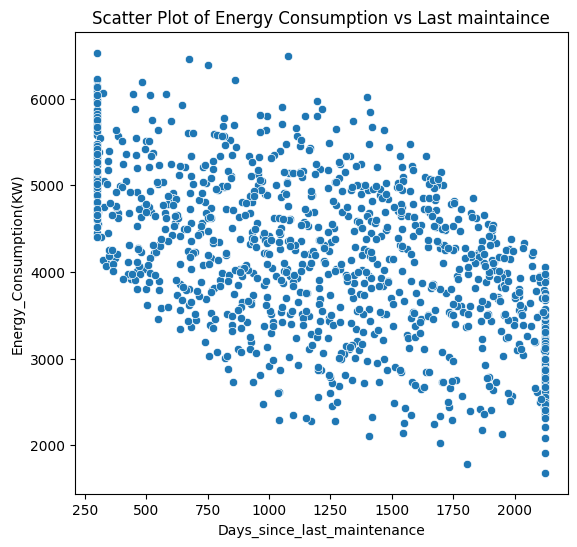

Correlation between time since maintenance and energy consumption: -0.5514041436111478


In [27]:
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='Days_since_last_maintenance', y='Energy_Consumption(KW)', data=df, palette='magma', ax=ax)
ax.set_title('Scatter Plot of Energy Consumption vs Last maintaince')
plt.show()
correlation = df['Days_since_last_maintenance'].corr(df['Energy_Consumption(KW)'])
print("Correlation between time since maintenance and energy consumption:", correlation)

**Answer for Q4:** based on the graph when buildings have a higher days since last maintenance it appear to consume less energy also it is based on the negative corelation = -.55 same as the one above the scatter plot shwo the correaltion between 2 varibles most effectivle and it can be assumed from the visualization

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

Text(0, 0.5, 'Frequency')

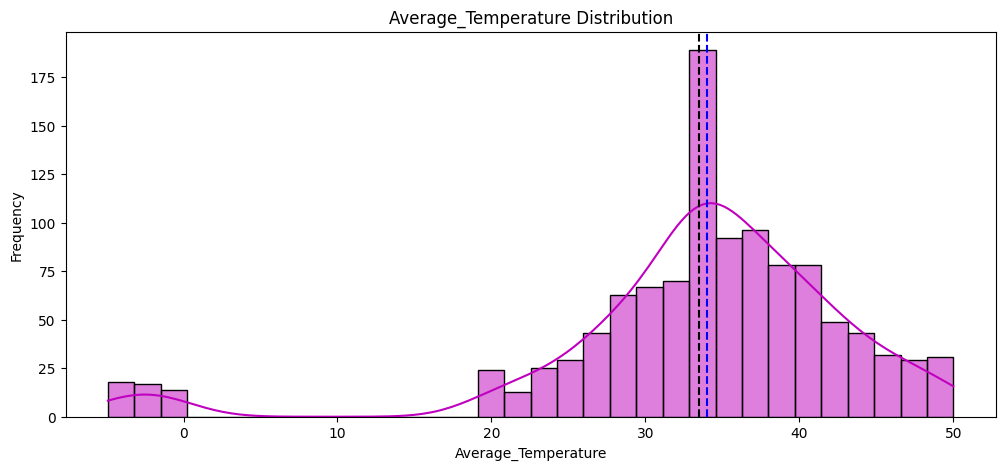

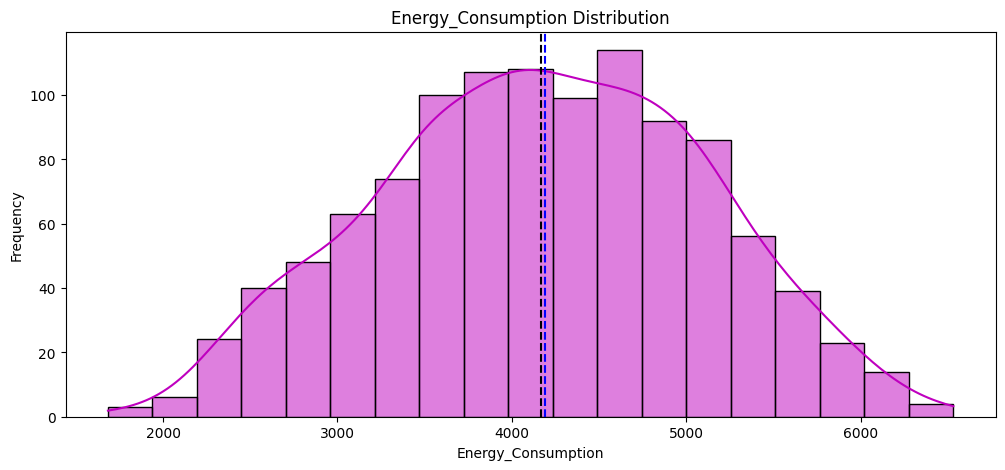

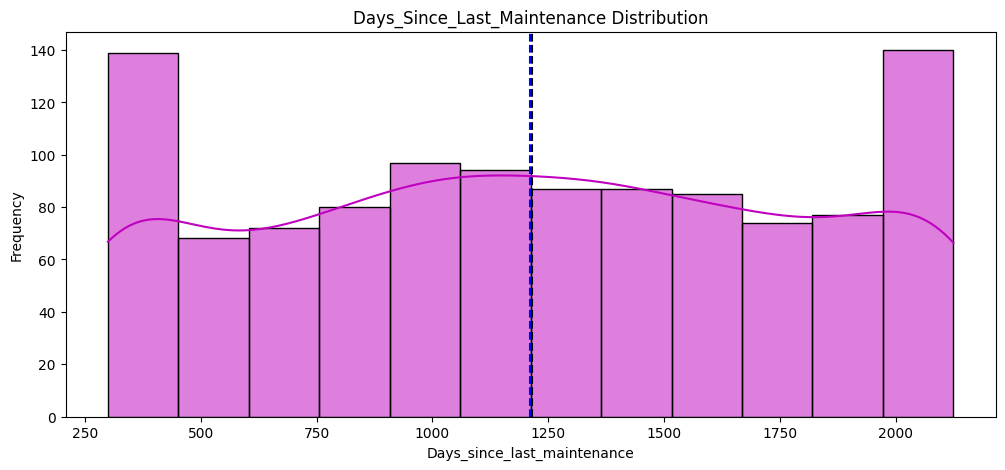

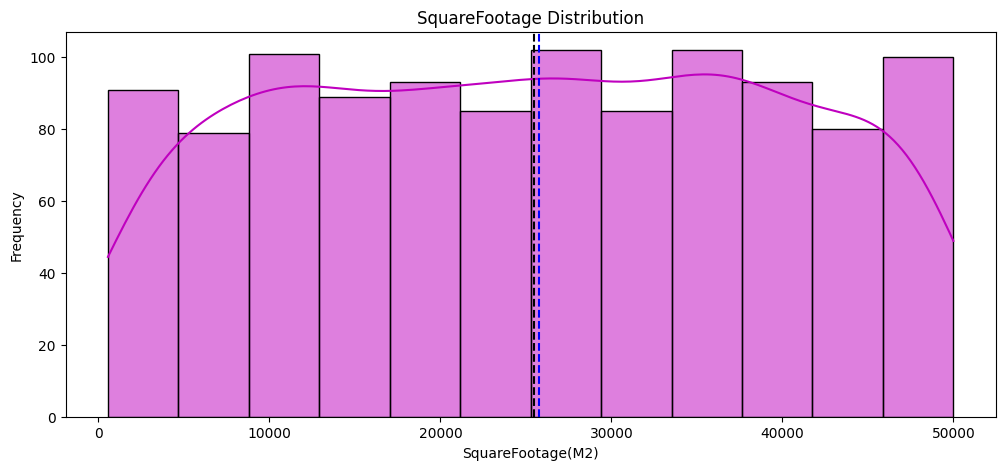

In [28]:
plt.figure(figsize=(12,5))
plt.title('Average_Temperature Distribution')
ax = sns.histplot(df['Average_Temperature'], color='m', kde=True)
ax.axvline(df['Average_Temperature'].mean(), color='k', linestyle='--', label='Mean')
ax.axvline(df['Average_Temperature'].median(), color='b', linestyle='--', label='Median')

plt.xlabel('Average_Temperature')
plt.ylabel('Frequency')


plt.figure(figsize=(12,5))
plt.title('Energy_Consumption Distribution')
ax = sns.histplot(df['Energy_Consumption(KW)'], color='m', kde=True)
ax.axvline(df['Energy_Consumption(KW)'].mean(), color='k', linestyle='--', label='Mean')
ax.axvline(df['Energy_Consumption(KW)'].median(), color='b', linestyle='--', label='Median')

plt.xlabel('Energy_Consumption')
plt.ylabel('Frequency')


# --- Days_Since_Last_Maintenance ---
plt.figure(figsize=(12,5))
plt.title('Days_Since_Last_Maintenance Distribution')
ax = sns.histplot(df['Days_since_last_maintenance'], color='m', kde=True)
ax.axvline(df['Days_since_last_maintenance'].mean(), color='k', linestyle='--', label='Mean')
ax.axvline(df['Days_since_last_maintenance'].median(), color='b', linestyle='--', label='Median')
plt.xlabel('Days_since_last_maintenance')
plt.ylabel('Frequency')



# --- SquareFootage ---
plt.figure(figsize=(12,5))
plt.title('SquareFootage Distribution')
ax = sns.histplot(df['SquareFootage(M2)'], color='m', kde=True)
ax.axvline(df['SquareFootage(M2)'].mean(), color='k', linestyle='--', label='Mean')
ax.axvline(df['SquareFootage(M2)'].median(), color='b', linestyle='--', label='Median')
plt.xlabel('SquareFootage(M2)')
plt.ylabel('Frequency')

#plt.figure(figsize=(12,5))
#plt.title('Building_Type_Encoded Distribution')
#ax = sns.histplot(df['Building_Type_Encoded'], color='m', kde=True)
#ax.axvline(df['Building_Type_Encoded'].mean(), color='k', linestyle='--', label='Mean')
#ax.axvline(df['Building_Type_Encoded'].median(), color='b', linestyle='--', label='Median')
#plt.xlabel('Building_Type_Encoded')
#plt.ylabel('Frequency')

In [29]:
print("Average_Temperature skewness:", df['Average_Temperature'].skew())
print("Energy_Consumption skewness:", df['Energy_Consumption(KW)'].skew())
print("Days_since_last_maintenance skewness:", df['Days_since_last_maintenance'].skew())
print("SquareFootage skewness:", df['SquareFootage(M2)'].skew())


Average_Temperature skewness: -1.7956354307565128
Energy_Consumption skewness: -0.060156096964443996
Days_since_last_maintenance skewness: -0.01663334106002565
SquareFootage skewness: -0.009364421250644675


**Answer for Q5:** for Average_Temperature = since the skewness in >-1 so it is highly skewed for the rest of the graphes since they are closer to 0 it approximately normaly distributed here we wanted to measure the distribtuoon so the distribution graph was the best option and it also present the median and the mean of the distribution bill shape diagram is the best use for the distribution model





**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

Index(['SquareFootage(M2)', 'Average_Temperature', 'Energy_Consumption(KW)',
       'Days_since_last_maintenance', 'Building_Type_Commercial',
       'Building_Type_Industrial', 'Building_Type_Residential'],
      dtype='object')
                             SquareFootage(M2)  Average_Temperature  \
SquareFootage(M2)                     1.000000             0.368061   
Average_Temperature                   0.368061             1.000000   
Energy_Consumption(KW)                0.770765             0.445172   
Days_since_last_maintenance          -0.420811            -0.243218   
Building_Type_Commercial             -0.003519             0.039666   
Building_Type_Industrial              0.022308             0.148453   
Building_Type_Residential            -0.018041            -0.179812   

                             Energy_Consumption(KW)  \
SquareFootage(M2)                          0.770765   
Average_Temperature                        0.445172   
Energy_Consumption(KW)              

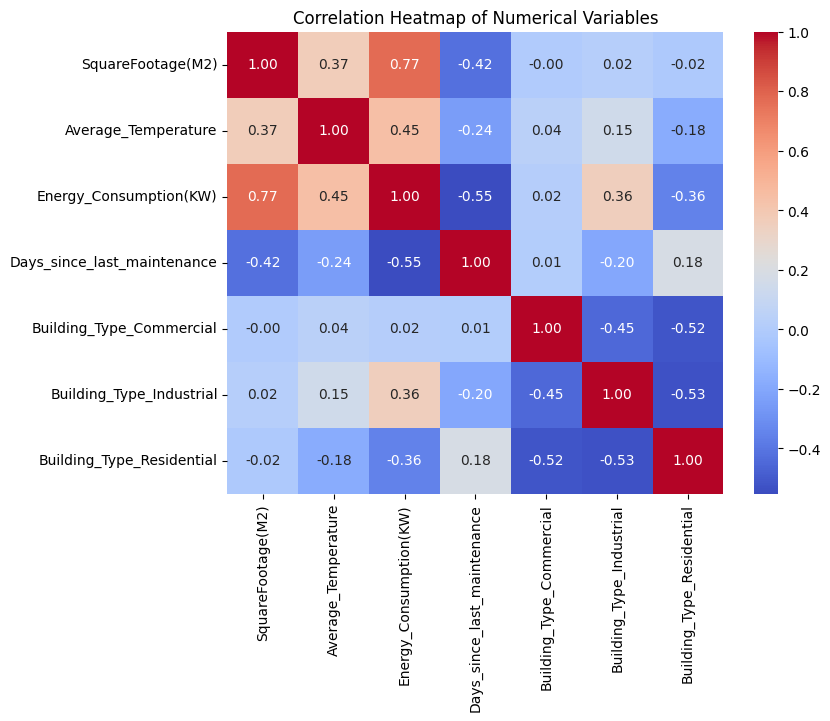

In [30]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
print(numeric_df.columns)
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()


**Answer for Q6:** multi colineartiy two or more independent variables in a model are highly correlated with each other and this isnt good for regression beacuse in regression we need orthogonal independent variables and having highly correalted vairbales may lead to inflated or deflated parameter estimates. and in our data set we dont majorly have this problem because as displayed there is no highly corelation between variables the highest we have is 0.77 between consumption and space of buliding

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

the step of encoding have been already done above using lable encding by giving the value a special integar (1,2,3)

first of all we displayed all the columns we have and after doing our preprocessing above we came to a interpertation that the id,type "as categorical names", neighborhood , day of week , last maintaince date wont be needed in our modelling becuase they wont affect our results as much they wont hold value in the next steps
because later on for our linear regression model we will want to include vairable that are corralted but not highly ocrrealted so our resluts doesnt get affected
- and forthe selected features they represent the corelated independence variable that is orthogonal

In [31]:
df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage(M2),Last_Maintenance_Date,Average_Temperature,Energy_Consumption(KW),Days_since_last_maintenance,Day_type,Building_Type_Commercial,Building_Type_Industrial,Building_Type_Residential
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063,2020-01-01,28.610000,2713.95,2125,weekday,0,0,1
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372,2022-02-24,33.499404,5744.99,1340,weekday,1,0,0
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255,2021-02-22,37.880000,4101.24,1707,weekday,0,1,0
3,BLD-1003-HE,Industrial,Giza,Dokki,Tuesday,Low,High,13265,2023-07-30,35.060000,3009.14,819,weekday,0,1,0
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.820000,3279.17,1171,weekday,1,0,0


In [32]:
columns_to_drop = ['Building_ID', 'Governorate', 'Neighborhood', 'Day_of_Week', 'Last_Maintenance_Date', 'Occupancy_Level', 'Appliances_Usage_Level', 'Day_type', 'Building_Type','Building_Type_Commercial']
df = df.drop(columns=columns_to_drop)

display(df.head())

,SquareFootage(M2),Average_Temperature,Energy_Consumption(KW),Days_since_last_maintenance,Building_Type_Industrial,Building_Type_Residential
0,7063,28.610000,2713.95,2125,0,1
1,44372,33.499404,5744.99,1340,0,0
2,19255,37.880000,4101.24,1707,1,0
3,13265,35.060000,3009.14,819,1,0
4,13375,28.820000,3279.17,1171,0,0


Normalizing the independent values only to be in range for all values using Min,Max method

In [33]:
numerical_columns = ['SquareFootage(M2)', 'Average_Temperature', 'Days_since_last_maintenance']


df[numerical_columns] = (

    df[numerical_columns] - df[numerical_columns].min()

) /(

    df[numerical_columns].max() - df[numerical_columns].min()
)


df.head()

,SquareFootage(M2),Average_Temperature,Energy_Consumption(KW),Days_since_last_maintenance,Building_Type_Industrial,Building_Type_Residential
0,0.131541,0.610453,2713.95,1.000000,0,1
1,0.886219,0.699497,5744.99,0.570099,0,0
2,0.378158,0.779275,4101.24,0.771084,1,0
3,0.256994,0.727918,3009.14,0.284775,1,0
4,0.259219,0.614278,3279.17,0.477547,0,0


## Modelling

_Apply the linear regression model below._

splitting data for train and test 80 training , 20 testing

In [34]:

x = df.drop('Energy_Consumption(KW)',axis=1) # Independent variable
y = df['Energy_Consumption(KW)'] # Dependent variable

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=23)

print('Training dataset size:', x_train.shape[0])
print('Testing dataset size:', x_test.shape[0])

Training dataset size: 880
Testing dataset size: 220


model building

In [35]:

lin_reg = LinearRegression()

lin_reg.fit(x_train, y_train);

In [36]:
parameter = ['theta_0'] + ['theta_{}'.format(i+1) for i in range(x.shape[1])]
columns = ['y-intersect'] + list(x.columns.values)
sk_theta = pd.Series([lin_reg.intercept_] + list(lin_reg.coef_))

parameter_df = pd.DataFrame({'parameter':parameter,'column':columns, 'theta_value': sk_theta})
parameter_df

,parameter,column,theta_value
0,theta_0,y-intersect,3101.810049
1,theta_1,SquareFootage(M2),2095.270602
2,theta_2,Average_Temperature,424.443786
3,theta_3,Days_since_last_maintenance,-533.212111
4,theta_4,Building_Type_Industrial,359.200422
5,theta_5,Building_Type_Residential,-366.438304


Y=3736.366466+2095.119898(SquareFootage)+424.666736(Average_temprature)-533.344660(Days_since_last_maintaince)+2.412627(Building_Type_Commercia)+361.613049(Building_Type_Industrial)+-364.025677(Building_Type_Residential)
These coefficients indicate the direction and magnitude of the relationship between each independent variable and the energy consumption according to this trained model.

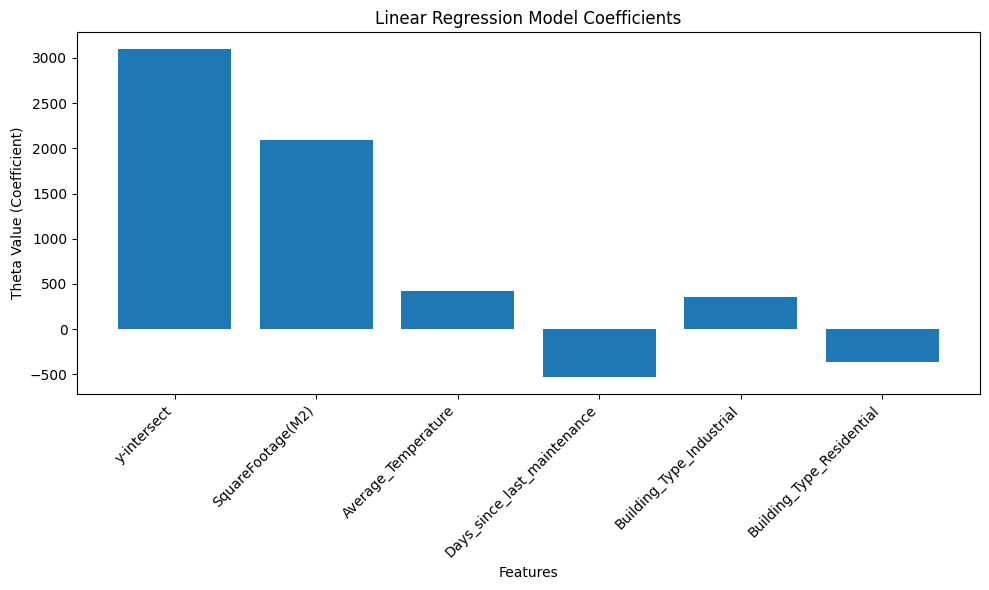

In [37]:
plt.figure(figsize=(10, 6))
plt.bar(parameter_df['column'], parameter_df['theta_value'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Theta Value (Coefficient)')
plt.title('Linear Regression Model Coefficients')
plt.tight_layout()
plt.show()

bars as telling you how much each factor affect the energy consumption up or down. If a bar goes upwards (is positive), it means that as that factor increases, the energy usage tends to climb. The higher the bar, the bigger the effect. On the flip side, if a bar goes downwards (is negative), an increase in that factor is associated with a drop in energy use – again, the further down it goes, the stronger that inverse relationship. The sheer height of a bar, whether up or down, gives you a sense of how much punch that feature packs in influencing energy consumption compared to the others. The 'y-intercept' bar is essentially your starting point, representing the estimated energy use when all the other factors are at their zero mark. So, by glancing at this plot, you get a quick feel for which elements are the big players in determining energy consumption and which way they sway the needle.

## Model Evaluation

Evaluate the model you applied.

In [38]:
y_pred = lin_reg.predict(x_test)

# Evaluation

#If you are using a local python notebook uncomment the RMSE line below and run
#from sklearn.metrics import mean_squared_error
#rmse = mean_squared_error(y_pred, y_test, squared=False)

#If you are using a cloud python notebook run the below RSME line
from sklearn.metrics import root_mean_squared_error
rmse=root_mean_squared_error(y_pred, y_test)

# R_square
R_square = lin_reg.score(x_test,y_test)
print('The root mean square error (RMSE) is: ', rmse)
print('R^2 obtained is:', R_square)

The root mean square error (RMSE) is:  450.4155080520452
R^2 obtained is: 0.7721409974146903


## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**:



In [39]:
display(df['Energy_Consumption(KW)'].describe())

,Energy_Consumption(KW)
count,1100.000000
mean,4168.191273
std,924.278723
min,1683.950000
25%,3510.460000
50%,4189.690000
75%,4859.510000
max,6530.600000


The RMSE of 450.41 means that, on average, the models predictions are off by about 450 units from the actual values. Since the average value in your dataset is around 4168, this error is roughly 10% of the typical value. In simple terms, the model is doing a pretty good jobits not perfect, but its reasonably accurate for most practical uses. The predictions are close to reality most of the time, though theres still some room to make the model even better.

 The linear regression model's R^2
 score is 0.77 What is considered a good because for companies R^2 greater than 0.3 is considered good the larger the R-squared value, the more precisely the predictor variables are able to predict the value of the response variable. and it also means it cover alot of variance available it explain 77% of variance in the data

yes i will recomend it for the company since it is higher than .3 in R2 and the preformance matrix preform well

Problems and Possible Solutions:

Moderate RMSE: While the R-squared is good, an RMSE of 450.41 might still be too high for certain applications requiring very precise energy consumption estimates.

 Solutions:
 Feature Engineering: Explore creating more features or transforming existing ones. For example, considering interactions between features (e.g., SquareFootage * Building_Type) .
 Include More Data: A larger dataset with more diverse scenarios might improve the model's ability to generalize.
       

Categorical Feature Encoding: While label encoding was used for some categorical features, it assumes an ordinal relationship which might not be accurate (e.g., for Governorate or Neighborhood).

Solutions:
One-Hot Encoding: Revisit using one-hot encoding for nominal categorical variables like Governorate and Neighborhood. This avoids implying a false sense of order.



# **Bonus** part removing outliers

first we will remove outliers for energy consumption days since last amintaince squarefootge using z table because they are approximatly normal distributed and IQR removal for the average tmp because it is highly skewed whcih this will work better for it

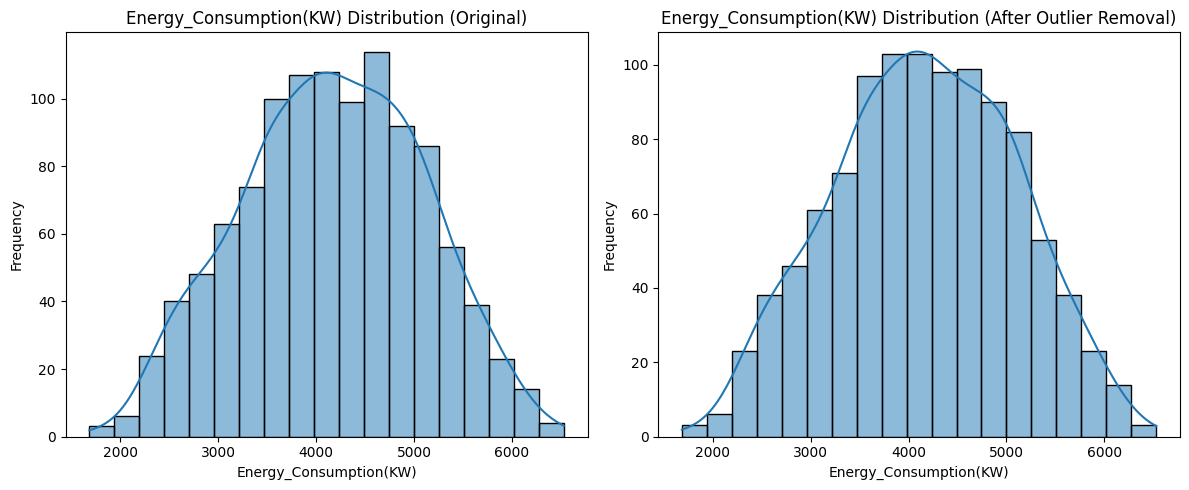

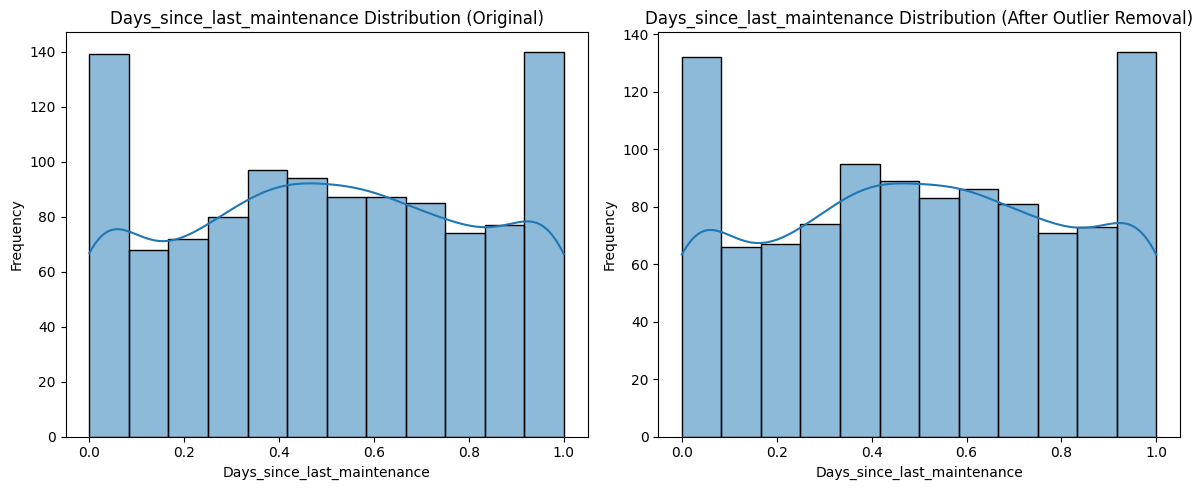

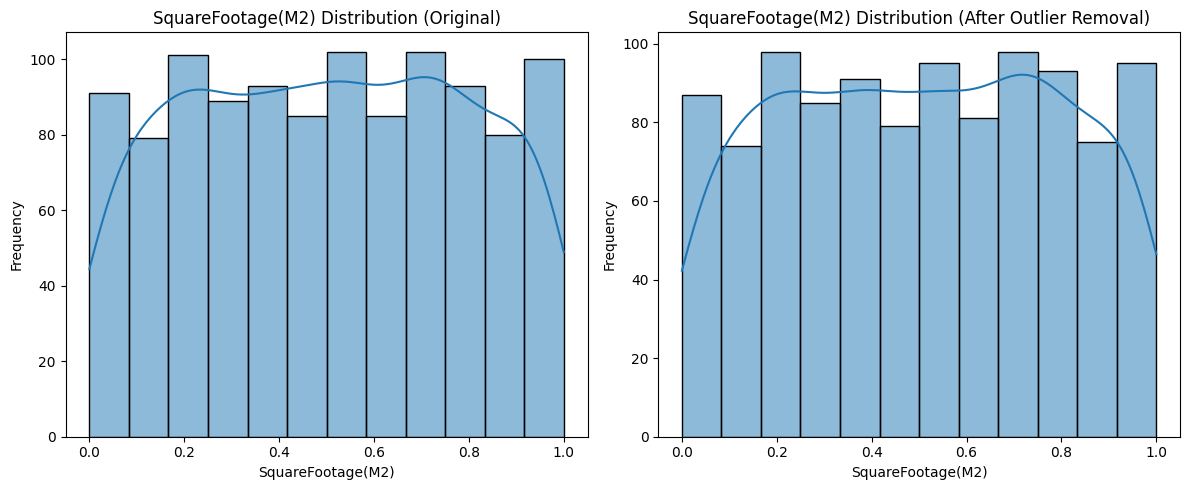

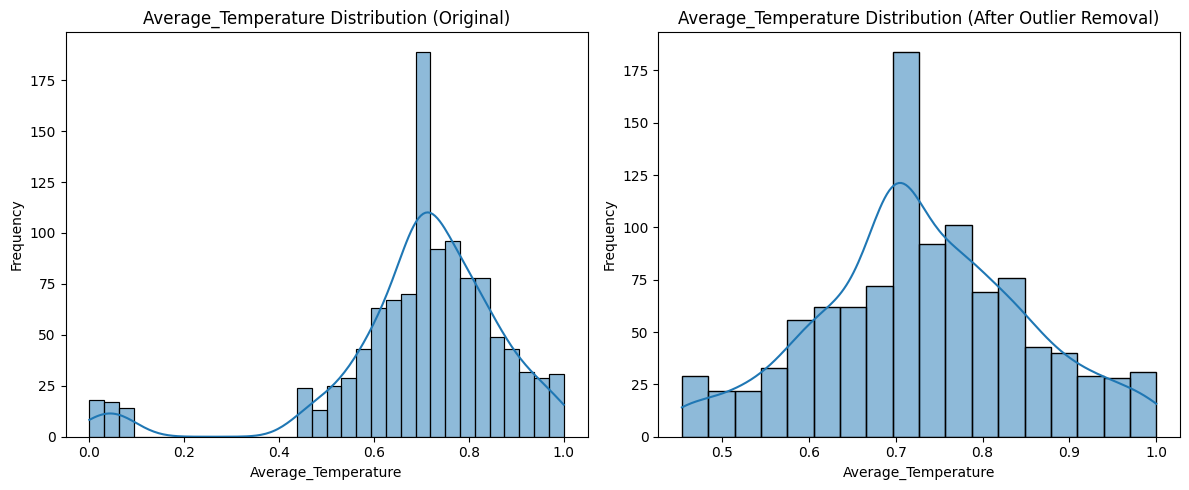

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

# Create a copy of the original dataframe for comparison
df_original = df.copy()

cols_zscore = ['Energy_Consumption(KW)', 'Days_since_last_maintenance', 'SquareFootage(M2)']
z = np.abs(stats.zscore(df[cols_zscore], nan_policy='omit'))
df_cleaned_zscore = df[(z < 3).all(axis=1)].copy()

Q1 = df['Average_Temperature'].quantile(0.25)
Q3 = df['Average_Temperature'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_cleaned = df_cleaned_zscore[(df_cleaned_zscore['Average_Temperature'] >= lower) & (df_cleaned_zscore['Average_Temperature'] <= upper)].copy()


cols_to_visualize = ['Energy_Consumption(KW)', 'Days_since_last_maintenance', 'SquareFootage(M2)', 'Average_Temperature']

for col in cols_to_visualize:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df_original[col], kde=True)
    plt.title(f'{col} Distribution (Original)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'{col} Distribution (After Outlier Removal)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

so as we can see since we knew that Energy_Consumption(KW)', 'Days_since_last_maintenance', 'SquareFootage(M2) were approxaimtly normally distributed indicateing no seever outliers there representaion didnt change alot howaever for the avg temprature it was higly skewed so when we applied the IQR to remove outliers that data became approximatelty normally distrubted whcih show the affect of having outliers on the model it can change the how representation of data the Z table was used because if the value is >3 after applign z model then it is far from the mean by 3 times whcih is considered an outlier

after visualizing and removing outliers lets check for the r and rmse

In [41]:
x = df_cleaned.drop('Energy_Consumption(KW)',axis=1) # Independent variable
y = df_cleaned['Energy_Consumption(KW)'] # Dependent variable

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=23)

print('Training dataset size:', x_train.shape[0])
print('Testing dataset size:', x_test.shape[0])


parameter = ['theta_0'] + ['theta_{}'.format(i+1) for i in range(x.shape[1])]
columns = ['y-intersect'] + list(x.columns.values)
sk_theta = pd.Series([lin_reg.intercept_] + list(lin_reg.coef_))

parameter_df = pd.DataFrame({'parameter':parameter,'column':columns, 'theta_value': sk_theta})
parameter_df



y_pred = lin_reg.predict(x_test)

# Evaluation

#If you are using a local python notebook uncomment the RMSE line below and run
#from sklearn.metrics import mean_squared_error
#rmse = mean_squared_error(y_pred, y_test, squared=False)

#If you are using a cloud python notebook run the below RSME line
from sklearn.metrics import root_mean_squared_error
rmse=root_mean_squared_error(y_pred, y_test)

# R_square
R_square = lin_reg.score(x_test,y_test)
print('The root mean square error (RMSE) is: ', rmse)
print('R^2 obtained is:', R_square)

Training dataset size: 840
Testing dataset size: 211
The root mean square error (RMSE) is:  387.43850008426165
R^2 obtained is: 0.8029106797366687


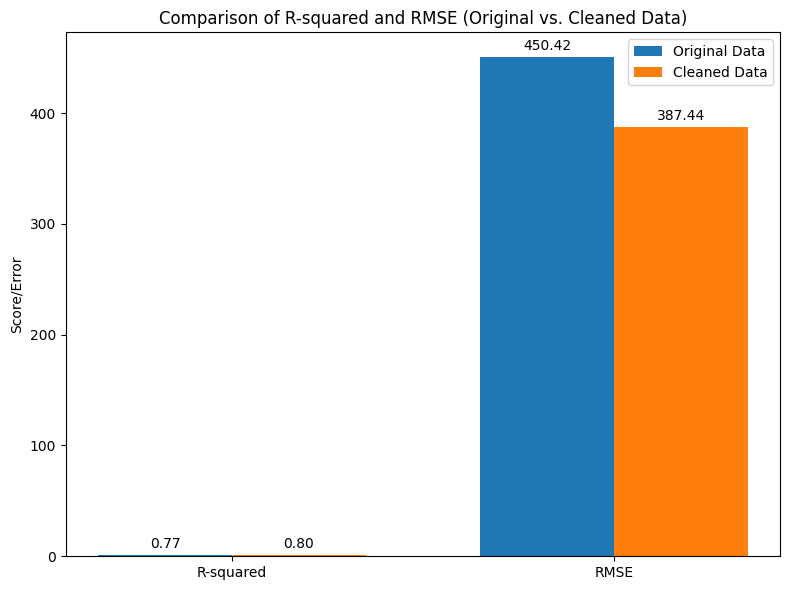

In [42]:
# Assuming you have the R^2 and RMSE values stored in variables
# from both the original model and the cleaned model.
# For example:
# R_square_original = ...
# rmse_original = ...
# R_square_cleaned = ...
# rmse_cleaned = ...

# If you have just run the cells above, the variables R_square and rmse
# should contain the values from the cleaned data model.
# You might need to store the original values before running the cleaning steps.

# Let's assume the original values were stored as:
# R_square_original = 0.7721409974146903 # Replace with your actual original R^2
# rmse_original = 450.4155080520452 # Replace with your actual original RMSE

# Using the R_square and rmse from the last executed cell (cleaned data model)
R_square_cleaned = R_square
rmse_cleaned = rmse

# To get the original R^2 and RMSE, we need to re-run the model on the original data
# or ensure those values were stored before cleaning.
# For demonstration, let's assume we store the original values here:
# Note: In a real scenario, you would store these after running the model on the original data.
R_square_original = 0.7721409974146903
rmse_original = 450.4155080520452

metrics = ['R-squared', 'RMSE']
original_values = [R_square_original, rmse_original]
cleaned_values = [R_square_cleaned, rmse_cleaned]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, original_values, width, label='Original Data')
rects2 = ax.bar(x + width/2, cleaned_values, width, label='Cleaned Data')

ax.set_ylabel('Score/Error')
ax.set_title('Comparison of R-squared and RMSE (Original vs. Cleaned Data)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{:.2f}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

so we compared between the old results we had and the new results after we can understand why having outliers affect the model beofre removing them we had lower r^2 and higher rmse this was the outlier affect however after removing the outlier and re applying the model we can see that the r^2 got less by 0.03 and the rmse decreased to 387.44 whcih gave us even more accurate data resulting in more accurate predictions of energy consumption

Index(['SquareFootage(M2)', 'Average_Temperature', 'Energy_Consumption(KW)',
       'Days_since_last_maintenance', 'Building_Type_Industrial',
       'Building_Type_Residential'],
      dtype='object')
                             SquareFootage(M2)  Average_Temperature  \
SquareFootage(M2)                     1.000000             0.580086   
Average_Temperature                   0.580086             1.000000   
Energy_Consumption(KW)                0.772238             0.732440   
Days_since_last_maintenance          -0.427641            -0.408683   
Building_Type_Industrial              0.025224             0.255710   
Building_Type_Residential            -0.021105            -0.263458   

                             Energy_Consumption(KW)  \
SquareFootage(M2)                          0.772238   
Average_Temperature                        0.732440   
Energy_Consumption(KW)                     1.000000   
Days_since_last_maintenance               -0.554822   
Building_Type_Industrial 

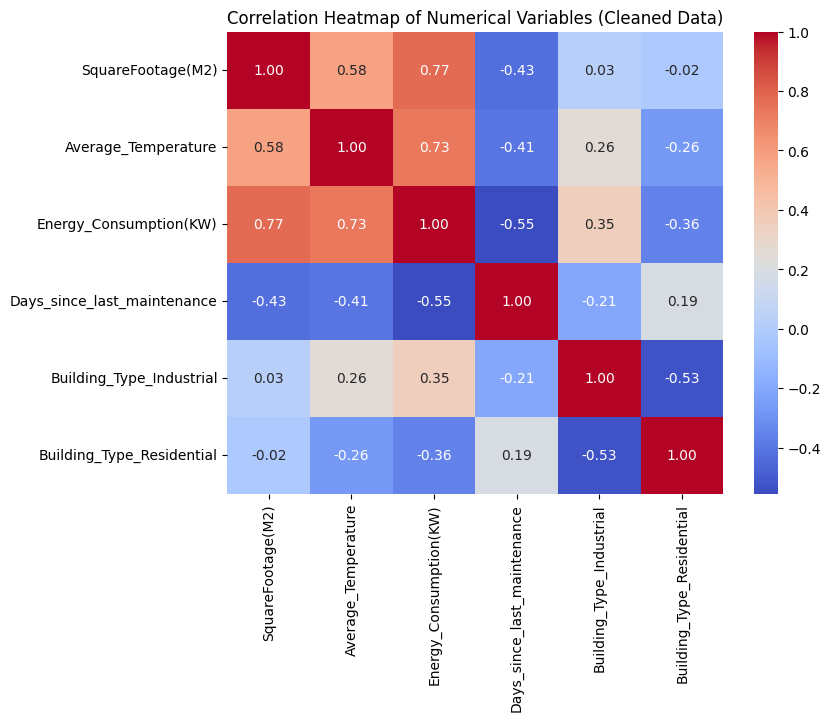

In [43]:
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
print(numeric_df.columns)
corr_matrix = numeric_df.corr()
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables (Cleaned Data)')
plt.show()

the corelation with the average temprature have been significantly raise after removing the outliers because data become more oriented